In [ ]:
from pathlib import Path
import xarray as xr
from  dask.distributed import Client

import numpy as np

### 0. Check that we're on the right machine - this is for a compute node

In [ ]:
import os
import psutil

# Check CPU Cores
logical_cores = os.cpu_count()
physical_cores = psutil.cpu_count()

# Check Memory (RAM)
virtual_mem = psutil.virtual_memory()
total_memory_gb = virtual_mem.total / (1024 ** 3)

print(f"Logical CPU Cores: {logical_cores}")
print(f"Physical CPU Cores: {physical_cores}")
print(f"Total System Memory: {total_memory_gb:.2f} GB") 

Logical CPU Cores: 28
Physical CPU Cores: 28
Total System Memory: 125.77 GB


In [ ]:
import socket

print(socket.gethostname())

n97.clstr


### 1. Settings and get a Dask client up and running

In [ ]:
resolution = 4


years = [str(yr) for yr in range(1959, 2023)]
months = [str(item).zfill(2) for item in range (1, 13)]
filepattern = f"era5_wrf_dscale_{resolution}km"
datadir = Path(f"/import/SNAP/cwaigl/wrf_era5/{str(resolution).zfill(2)}km/")
dirlist = []
for yr in years:
    dirlist.extend([p for p in datadir.joinpath(yr).glob(f"{filepattern}_*.nc")])
client = Client(n_workers=14, threads_per_worker=2, memory_limit='8GB')
print(client)

<Client: 'tcp://127.0.0.1:42339' processes=14 threads=28, memory=104.31 GiB>


2026-06-07 22:02:48,449 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 15b8938dbea9fc7a2981b04c005e3b3e initialized by task ('rechunk-merge-rechunk-transfer-fe52eac2452d5a275c0e8d07dc2600f9', 0, 2, 1, 20, 3, 2) executed on worker tcp://127.0.0.1:36853
2026-06-07 22:02:48,468 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle def4d8672215d97a143e05e709379d58 initialized by task ('rechunk-merge-rechunk-transfer-fe52eac2452d5a275c0e8d07dc2600f9', 0, 1, 2, 20, 2, 3) executed on worker tcp://127.0.0.1:36853
2026-06-07 22:02:48,532 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4ffe84f1e2e79618eec7555d79bfe774 initialized by task ('rechunk-merge-rechunk-transfer-fe52eac2452d5a275c0e8d07dc2600f9', 0, 2, 2, 20, 3, 3) executed on worker tcp://127.0.0.1:36853
2026-06-07 22:02:54,835 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c0a1d028d845fe1f84cefaea04220dc2 initialized by task ('rechunk-merge-rechunk-transfer-fe52eac2452d5a275c0e8d07dc2600f9', 

In [ ]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 14
Total threads: 28,Total memory: 104.31 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42339,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36853,Total threads: 2
Dashboard: http://127.0.0.1:33079/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:40689,


In [ ]:
len(dirlist)

23376

In [ ]:
# This should have happened earlier, but better late than never I guess

import dask

dask.config.set(**{'array.slicing.split_large_chunks': True})

### 2. Open the dataset, if necessary with random subsampling to reduce the Dask graph size for testing

In [ ]:
subsample = True
percentage = 0.1
if subsample:

    np.random.seed(42) 
    sample_size = max(1, int(len(dirlist) * percentage)) 
    sampled_files = np.random.choice(dirlist, size=sample_size, replace=False)
else:
    sampled_files = dirlist

In [ ]:
ds = xr.open_mfdataset(
    sampled_files, 
    parallel=True, 
    # chunks={'Time': 8760, 'south_north': 20, 'west_east': 20},  
    chunks={'Time': 8760},
    data_vars=["wspd10"], 
    coords="minimal", 
    compat="override"
)

In [ ]:
# let's rechunk for computation

ds_for_calc = ds.chunk({"Time": -1, "south_north": 20, "west_east": 20})
ds_for_calc

<xarray.Dataset> Size: 6TB
Dimensions:       (Time: 56088, south_north: 450, west_east: 420,
                   interp_level: 9, soil_layers_stag: 4)
Coordinates:
  * Time          (Time) datetime64[ns] 449kB 1959-01-09 ... 2022-12-28T23:00:00
    XLONG         (south_north, west_east) float32 756kB dask.array<chunksize=(20, 20), meta=np.ndarray>
    XLAT          (south_north, west_east) float32 756kB dask.array<chunksize=(20, 20), meta=np.ndarray>
    XTIME         (Time) float32 224kB dask.array<chunksize=(56088,), meta=np.ndarray>
  * interp_level  (interp_level) float64 72B 200.0 300.0 500.0 ... 950.0 1e+03
Dimensions without coordinates: south_north, west_east, soil_layers_stag
Data variables: (12/43)
    slp           (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
    ctt           (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
    dbz           (Time, interp_level, south_north, west_east) float32 382GB dask.array<chunksize=(56088, 3, 20, 20), meta=np.ndarray>
    rh2           (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
    T2            (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
    Q2            (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
    ...            ...
    u             (Time, interp_level, south_north, west_east) float32 382GB dask.array<chunksize=(56088, 3, 20, 20), meta=np.ndarray>
    v             (Time, interp_level, south_north, west_east) float32 382GB dask.array<chunksize=(56088, 3, 20, 20), meta=np.ndarray>
    w             (Time, interp_level, south_north, west_east) float32 382GB dask.array<chunksize=(56088, 3, 20, 20), meta=np.ndarray>
    rainnc        (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
    rainc         (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
    acsnow        (Time, south_north, west_east) float32 42GB dask.array<chunksize=(56088, 20, 20), meta=np.ndarray>
Attributes:
    date:     2024-04-24T20:24:39.161343
    data:     Downscaled ERA5 using WRF
    info:     Alaska Climate Adaptation Science Center, University of Alaska ...
    contact:  cwaigl@alaska.edu
    version:  WRF V4.5.1 - project v. 1.1

### 3.1 Calculate the 90th and 95th percentiles across the entire time dimension (lazy Dask operation)

In [ ]:
full_percentiles = ds_for_calc["wspd10"].quantile([0.90, 0.95], dim='Time')


In [ ]:
full_percentiles.to_netcdf('final_hourly_percentiles_90_95.nc')

### 3.2. calculate seasonal percentiles (DJF, MAM, JJA, SON)

In [ ]:
seasons = ["DJF", "MAM", "JJA", "SON"]
seasonal_percentiles = []

for season in seasons:
    # 1. Lazily filter for just the current season's months
    # This keeps the time chunks manageable
    ds_season = ds_for_calc.sel(time=ds_for_calc.Time.dt.season == season)
    
    # 2. Calculate the 90th and 95th percentile for this specific season
    per_season = ds_season["wspd10"].quantile([0.90, 0.95], dim="Time")
    
    # 3. Add a coordinate label so we can merge them later
    per_season = per_season.assign_coords(season=season)
    seasonal_percentiles.append(per_season)

# Combine the individual seasons into one compact dataset
# Shape will be: (quantile: 2, season: 4, latitude: 420, longitude: 450)
ds_seasonal_per = xr.concat(seasonal_percentiles, dim="season")

# Save this small baseline dataset to disk immediately so you don't lose it
ds_seasonal_per.to_netcdf("seasonal_percentiles_90_95.nc")

<xarray.DataArray 'wspd10' (quantile: 2, south_north: 450, west_east: 420)> Size: 3MB
dask.array<transpose, shape=(2, 450, 420), dtype=float64, chunksize=(2, 25, 23), chunktype=numpy.ndarray>
Coordinates:
    XLONG     (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLAT      (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
  * quantile  (quantile) float64 16B 0.5 0.9
Dimensions without coordinates: south_north, west_east

### 3.3. Calculate annual excedance counts

In [ ]:
# Load the static percentiles we just saved (breaks the heavy Dask graph dependency)
thresh = xr.open_dataset("seasonal_percentiles_90_95.nc")

# Broadcast the seasonal thresholds across the 65-year timeline
time_seasons = ds_for_calc.Time.dt.season
thresh_broadcasted = thresh["wspd10"].sel(season=time_seasons)

# Perform a lazy boolean comparison (True = 1, False = 0)
# This evaluates: Is the hourly value greater than its specific seasonal percentile?
is_exceedance = ds_for_calc["wspd10"] > thresh_broadcasted

# 3. Group by year and SUM the True values (hours)
# Because it's a sum of booleans, it tells you exactly how many hours exceeded the limit
annual_exceedances = is_exceedance.groupby("Time.year").sum(dim="Time")

# 4. Stream the final output directly to a new NetCDF file
annual_exceedances.to_netcdf("annual_exceedance_counts_90_95.nc")

In [ ]:
client.close()

### THIS IS ALL plotting code, IGNORE EVERYTHING BELOW THIS LINE if on HPC system

### Reload and plot

In [ ]:
full_percentiles = xr.open_dataarray('final_hourly_percentiles_50_95.nc')
full_percentiles

<xarray.DataArray 'wspd10' (quantile: 2, south_north: 450, west_east: 420)> Size: 3MB
[378000 values with dtype=float64]
Coordinates:
    XLONG     (south_north, west_east) float32 756kB ...
    XLAT      (south_north, west_east) float32 756kB ...
  * quantile  (quantile) float64 16B 0.5 0.9
Dimensions without coordinates: south_north, west_east

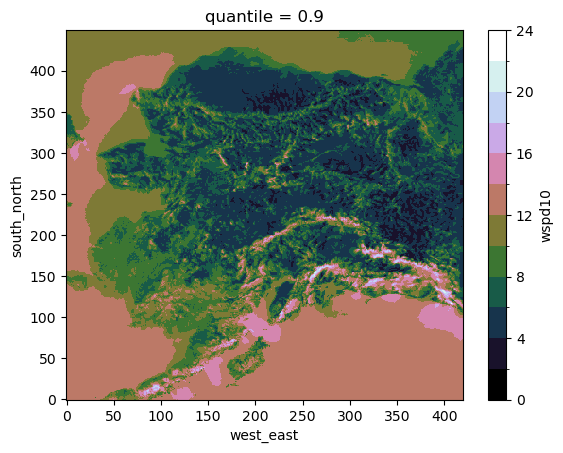

In [ ]:
full_percentiles_old.sel(quantile=0.90).plot(levels=list(np.linspace(0, 24, 13)), cmap='cubehelix')

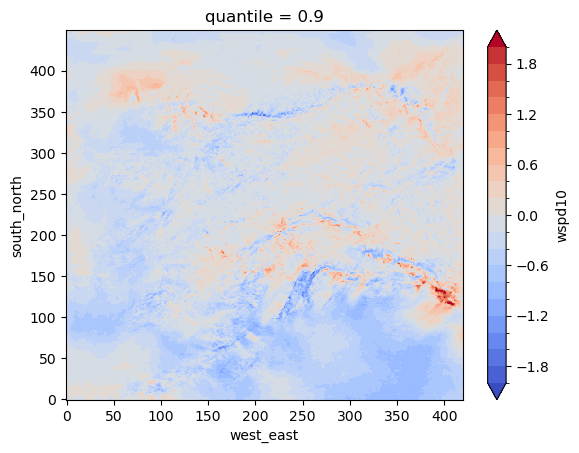

In [ ]:
full_percentiles_old = xr.open_dataarray('final_hourly_percentiles_50_90.nc')
(full_percentiles_old.sel(quantile=0.90) - full_percentiles.sel(quantile=0.90)).plot(levels=list(np.linspace(-2, 2, 21)), cmap='coolwarm')